# LLM Polarization Analysis - GSS Issues

This notebook analyzes LLM polarization on General Social Survey (GSS) policy issues.

Uses `TOPICS_GSS` from config to generate prompts and compares results with GSS survey polarization data.

In [6]:
import pandas as pd
import numpy as np
from datetime import datetime

# Import utilities
from config import TOPICS_GSS, DEFAULT_MODEL_PATH, DEFAULT_BATCH_SIZE
from model_utils import load_model, extract_heads_batched
from metrics_utils import compute_all_head_metrics, summarize_metrics, add_derived_metrics
from prompt_utils import (
    create_politician_prompt_set,
    create_ideology_prompt_set,
    POLITICIAN_TEMPLATES,
    IDEOLOGY_TEMPLATES,
)
from pipeline import run_politician_pipeline, run_ideology_pipeline

/project/jevans/maxzhuyt/honest_llama_env/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/project/jevans/maxzhuyt/honest_llama_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

Adjust these settings as needed:

In [7]:
# Model settings
MODEL_PATH = DEFAULT_MODEL_PATH
BATCH_SIZE = 128

# For ideology prompts: number of samples per ideology level
N_PER_LEVEL = 10

# Use GSS topics
TOPICS_SUBSET = TOPICS_GSS  # Use all GSS topics

# Optional: Select subset for faster testing
# TOPICS_SUBSET = {k: v for k, v in list(TOPICS_GSS.items())[:10]}

print(f"Number of GSS topics: {len(TOPICS_SUBSET)}")
print(f"\nTopics: {list(TOPICS_SUBSET.keys())}")

Number of GSS topics: 138

Topics: ['natspac', 'natspacy', 'natenvir', 'natenviy', 'natheal', 'nathealy', 'natcity', 'natcityy', 'natcrime', 'natcrimy', 'natdrug', 'natdrugy', 'nateduc', 'nateducy', 'natrace', 'natracey', 'natarms', 'natarmsy', 'nataid', 'nataidy', 'natfare', 'natfarey', 'natroad', 'natsoc', 'natmass', 'natpark', 'natsci', 'natenrgy', 'natchld', 'polviews', 'govchrst', 'goveqinc', 'goveqinc1', 'govfnaid', 'govfnanc', 'govunemp', 'govineq1', 'govineq2', 'ldctax', 'hlthgov', 'eqwlth', 'helppoor', 'helpnot', 'helpsick', 'abany', 'abdefect', 'abnomore', 'abhlth', 'abpoor', 'abrape', 'absingle', 'abhelp1', 'abhelp2', 'abhelp3', 'abhelp4', 'pillok', 'letdie1', 'letdie1y', 'carsgen', 'grncon', 'grnecon', 'grnexagg', 'grnprog', 'grnprice', 'grnsol', 'grntaxes', 'grwtharm', 'grwthelp', 'harmsgrn', 'ihlpgrn', 'impgrn', 'toodifme', 'othssame', 'cappun', 'gunlaw', 'courts', 'grass', 'polhitok', 'polabuse', 'polescap', 'polmurdr', 'polattak', 'racdif1', 'racdif2', 'racdif3', 'racdi

## 2. Load Model

In [3]:
model, tokenizer = load_model(MODEL_PATH)

Loading model from: /project/jevans/maxzhuyt/models/Meta-Llama-3.1-8B-Instruct...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 4/4 [00:18<00:00,  4.72s/it]


## 3. Run Politician Prompt Analysis

This uses actual U.S. politician names from the NOMINATE dataset.

In [4]:
df_politician = run_politician_pipeline(
    model, tokenizer,
    topics=TOPICS_SUBSET,
    batch_size=BATCH_SIZE
)

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
df_politician.to_pickle(f"df_llm_gss_politician_{timestamp}.pkl")
print(f"Politician results shape: {df_politician.shape}")


POLITICIAN PROMPT PIPELINE

--- Topic: natspac ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
  > Done in 12.6s. Avg Mahalanobis: 1.7184

--- Topic: natspacy ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
  > Done in 8.8s. Avg Mahalanobis: 1.6817

--- Topic: natenvir ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
  > Done in 8.8s. Avg Mahalanobis: 1.7922

--- Topic: natenviy ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
  > Done in 8.8s. Avg Mahalanobis: 1.7220

--- Topic: natheal ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
  > Done in 8.9s. Avg Mahalanobis: 1.7382

--- Topic: nathealy ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
  > Done in 8.7s. Avg Mahalanobis: 1.6911

--- Topic: natcity ---
  > Extractin

## 4. Run Ideology Prompt Analysis

This uses generic ideological labels (extremely liberal -> extremely conservative).

In [5]:
# df_ideology = run_ideology_pipeline(
#     model, tokenizer,
#     topics=TOPICS_SUBSET,
#     batch_size=BATCH_SIZE,
#     n_per_level=N_PER_LEVEL
# )

# # Save results
# df_ideology.to_pickle(f"df_llm_gss_ideology_{timestamp}.pkl")
# print(f"Ideology results shape: {df_ideology.shape}")

## 4b. Load Previously Saved Results (Optional)

If you've already run the pipelines, you can load the saved results:

In [8]:
import glob

# Find the latest pickle files for GSS results
pol_files = glob.glob("df_llm_gss_politician_*.pkl")
#ideo_files = glob.glob("df_llm_gss_ideology_*.pkl")

if pol_files:
    pol_file = max(pol_files, key=lambda f: '_'.join(f.split('_')[-2:]))
    #ideo_file = max(ideo_files, key=lambda f: '_'.join(f.split('_')[-2:]))
    
    df_politician = pd.read_pickle(pol_file)
    #df_ideology = pd.read_pickle(ideo_file)
    
    print(f"Loaded politician file: {pol_file}")
    print(f"Politician results: {df_politician.shape}")
else:
    print("No saved GSS pickle files found. Please run the pipeline cells above first.")

Loaded politician file: df_llm_gss_politician_20260121_223916.pkl
Politician results: (138, 19)


In [4]:
pol_files

['df_llm_gss_politician_20260121_195401.pkl',
 'df_llm_gss_politician_20260121_221034.pkl',
 'df_llm_gss_politician_20260121_223916.pkl']

## 5. View Results

Both DataFrames contain the same columns with polarization metrics per topic.

In [9]:
# Display summary columns (excluding grid columns)
summary_cols = ['Topic', 'Avg_Mahalanobis', 'Avg_Total_Dispersion', 
                'Avg_PC1_Ratio', 'Avg_Davies_Bouldin', 'Polarization_CoG']

print("=== Politician Prompts ===")
display(df_politician[summary_cols].head(10))

# print("\n=== Ideology Prompts ===")
# display(df_ideology[summary_cols].head(10))

=== Politician Prompts ===


,Topic,Avg_Mahalanobis,Avg_Total_Dispersion,Avg_PC1_Ratio,Avg_Davies_Bouldin,Polarization_CoG
0,natspac,1.718422,0.027598,0.386091,9.226039,15.737059
1,natspacy,1.681669,0.027523,0.388690,9.336942,15.779855
2,natenvir,1.792166,0.028197,0.382541,8.080374,16.383082
3,natenviy,1.721991,0.030126,0.395404,8.728052,16.014587
4,natheal,1.738227,0.030095,0.397771,8.595632,16.045698
5,nathealy,1.691081,0.031447,0.401967,9.019785,15.926430
6,natcity,1.751462,0.026797,0.387719,8.630566,16.088797
7,natcityy,1.686639,0.027093,0.391734,8.920783,16.003770
8,natcrime,1.733549,0.028354,0.388074,9.039885,15.868736
9,natcrimy,1.692764,0.027322,0.391390,9.191155,15.848221


## 6. Compare with GSS Survey Polarization Data

In [10]:
# Load GSS polarization scores
df_gss = pd.read_csv("gss_polarization.csv")

# Rename columns to match expected format
df_gss = df_gss.rename(columns={
    "variable": "Topic", 
    "polarization": "GSS_Polarization",
})

print(f"GSS topics: {len(df_gss)}")
print(f"\nColumns: {df_gss.columns.tolist()}")
df_gss.head(10)

# exclude questions
EXCLUDE_QUESTIONS = [
    "eldfnce"
]
df_gss = df_gss[~df_gss['Topic'].isin(EXCLUDE_QUESTIONS)]

GSS topics: 138

Columns: ['Topic', 'area', 'GSS_Polarization', 'mean_dem', 'mean_rep', 'n_dem', 'n_rep', 'n_total', 'scale_range', 'direction']


In [11]:
def compare_with_gss(df_llm, df_gss, label="LLM"):
    """Merge LLM results with GSS and compute correlations."""
    df_llm_subset = df_llm[["Topic", "Avg_Mahalanobis", "Avg_Total_Dispersion"]].copy()
    
    df_merged = df_llm_subset.merge(df_gss, on="Topic", how="inner")
    
    # Compute correlations
    pearson = df_merged["Avg_Mahalanobis"].corr(df_merged["GSS_Polarization"], method="pearson")
    spearman = df_merged["Avg_Mahalanobis"].corr(df_merged["GSS_Polarization"], method="spearman")
    
    print(f"\n{label} vs GSS Polarization:")
    print(f"  Matched topics: {len(df_merged)}")
    print(f"  Pearson correlation: {pearson:.3f}")
    print(f"  Spearman correlation: {spearman:.3f}")
    
    return df_merged, pearson, spearman

# Compare both prompt types
df_pol_merged, pol_pearson, pol_spearman = compare_with_gss(df_politician, df_gss, "Politician Prompts")
# df_ideo_merged, ideo_pearson, ideo_spearman = compare_with_gss(df_ideology, df_gss, "Ideology Prompts")


Politician Prompts vs GSS Polarization:
  Matched topics: 125
  Pearson correlation: 0.521
  Spearman correlation: 0.523


In [12]:
df_merged = df_politician.merge(df_gss, on="Topic", how="inner")
# check: among all df_gss topics, which topics are not in df_politician
missing_topics = set(df_gss["Topic"]) - set(df_politician["Topic"])
print(f"Topics in GSS but not in Politician results: {missing_topics}")


Topics in GSS but not in Politician results: {'spkcomy', 'getaheadnv', 'helpfulv', 'spkmslmy', 'spkhomoy', 'libathy', 'busgrn', 'spkmily', 'spkracy', 'helpfulnv', 'spkathy', 'getaheadv'}


In [11]:
# View merged data sorted by GSS polarization
print("=== Politician Results (sorted by GSS Polarization) ===")
display(df_pol_merged.sort_values("GSS_Polarization", ascending=False)[
    ["Topic", "area", "Avg_Mahalanobis", "GSS_Polarization", "direction"]
].head(20))

=== Politician Results (sorted by GSS Polarization) ===


,Topic,area,Avg_Mahalanobis,GSS_Polarization,direction
70,racdif1,Race: Explanations for Inequality,1.778969,0.562443,Rep higher
41,abhelp2,Abortion: Circumstances for Legality & Support,1.859333,0.472126,Rep higher
35,abnomore,Abortion: Circumstances for Legality & Support,1.765604,0.470704,Rep higher
33,abany,Abortion: Circumstances for Legality & Support,1.802796,0.462417,Rep higher
37,abpoor,Abortion: Circumstances for Legality & Support,1.823116,0.446558,Rep higher
39,absingle,Abortion: Circumstances for Legality & Support,1.791310,0.443313,Rep higher
42,abhelp3,Abortion: Circumstances for Legality & Support,1.837470,0.439301,Rep higher
7,natrace,Race: Government Intervention & Affirmative Ac...,1.811579,0.418868,Rep higher
74,helpblk,Race: Government Intervention & Affirmative Ac...,1.827569,0.415418,Rep higher
29,eqwlth,Welfare & Redistribution Policy,1.745843,0.413940,Rep higher


## 7. Visualize Correlations

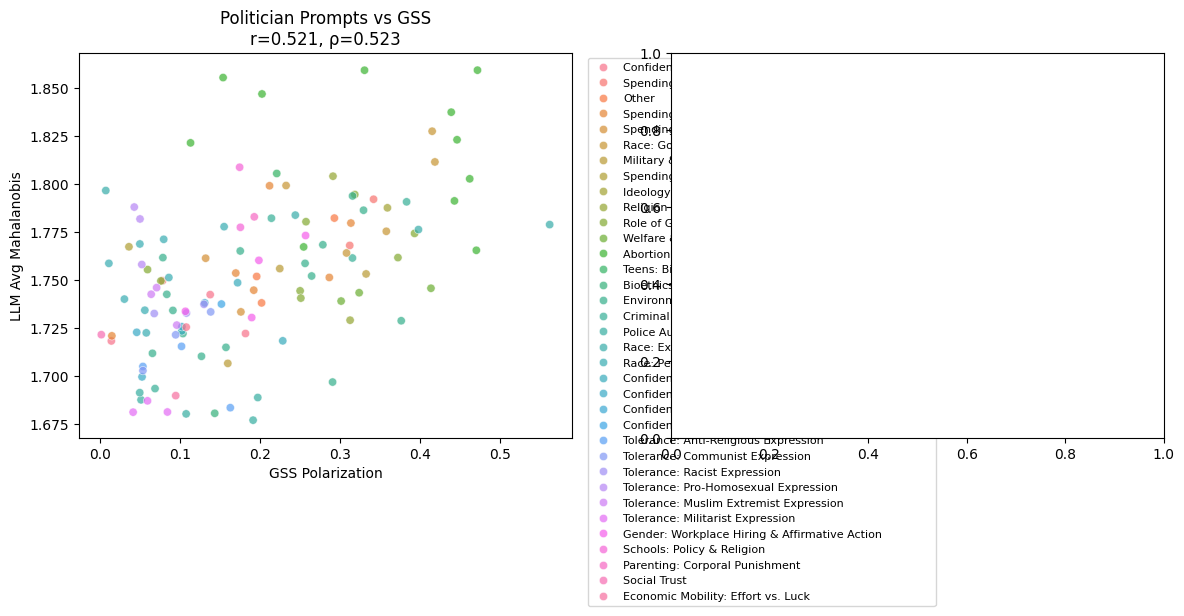

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Politician prompts scatter
ax1 = axes[0]
sns.scatterplot(data=df_pol_merged, x="GSS_Polarization", y="Avg_Mahalanobis", 
                hue="area", ax=ax1, alpha=0.7)
ax1.set_title(f"Politician Prompts vs GSS\nr={pol_pearson:.3f}, ρ={pol_spearman:.3f}")
ax1.set_xlabel("GSS Polarization")
ax1.set_ylabel("LLM Avg Mahalanobis")
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Ideology prompts scatter
# ax2 = axes[1]
# sns.scatterplot(data=df_ideo_merged, x="GSS_Polarization", y="Avg_Mahalanobis", 
#                 hue="area", ax=ax2, alpha=0.7)
# ax2.set_title(f"Ideology Prompts vs GSS\nr={ideo_pearson:.3f}, ρ={ideo_spearman:.3f}")
# ax2.set_xlabel("GSS Polarization")
# ax2.set_ylabel("LLM Avg Mahalanobis")
# ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# plt.tight_layout()
# plt.savefig("gss_llm_correlation_scatter.png", dpi=150, bbox_inches='tight')
# plt.show()

## 8. Z-Score Analysis

In [13]:
# Normalize politician and GSS polarization scores
df_pol_norm = df_pol_merged.copy()
df_pol_norm["LLM_z"] = (df_pol_norm["Avg_Mahalanobis"] - df_pol_norm["Avg_Mahalanobis"].mean()) / df_pol_norm["Avg_Mahalanobis"].std()
df_pol_norm["GSS_z"] = (df_pol_norm["GSS_Polarization"] - df_pol_norm["GSS_Polarization"].mean()) / df_pol_norm["GSS_Polarization"].std()
df_pol_norm["LLM_minus_GSS"] = df_pol_norm["LLM_z"] - df_pol_norm["GSS_z"]

# Sort by discrepancy
df_pol_norm_sorted = df_pol_norm.sort_values('LLM_minus_GSS', ascending=False)

print("Topics where LLM shows MORE polarization than GSS:")
display(df_pol_norm_sorted[["Topic", "area", "LLM_z", "GSS_z", "LLM_minus_GSS"]].head(10))

print("\nTopics where LLM shows LESS polarization than GSS:")
display(df_pol_norm_sorted[["Topic", "area", "LLM_z", "GSS_z", "LLM_minus_GSS"]].tail(10))

Topics where LLM shows MORE polarization than GSS:


,Topic,area,LLM_z,GSS_z,LLM_minus_GSS
43,abhelp4,Abortion: Circumstances for Legality & Support,2.551496,-0.304643,2.856139
71,racdif2,Race: Explanations for Inequality,1.092481,-1.442789,2.535270
36,abhlth,Abortion: Circumstances for Legality & Support,1.708274,-0.620479,2.328753
38,abrape,Abortion: Circumstances for Legality & Support,2.339963,0.072723,2.267239
105,spkhomo,Tolerance: Pro-Homosexual Expression,0.879195,-1.166643,2.045838
106,colhomo,Tolerance: Pro-Homosexual Expression,0.725226,-1.110782,1.836008
12,natsoc,Spending: Social Security,0.365980,-1.218117,1.584097
40,abhelp1,Abortion: Circumstances for Legality & Support,2.646432,1.067387,1.579046
83,marwht,Race: Perceived Group Differences & Social Dis...,0.151936,-1.412902,1.564838
118,sexeduc,Schools: Policy & Religion,1.393296,-0.144198,1.537494



Topics where LLM shows LESS polarization than GSS:


,Topic,area,LLM_z,GSS_z,LLM_minus_GSS
45,letdie1,Bioethics & End of Life,-1.784885,-0.385803,-1.399082
97,colath,Tolerance: Anti-Religious Expression,-1.712504,-0.234693,-1.477811
120,religinf,Religion in Public Life,-0.582211,0.927605,-1.509816
65,polhitok,Police Authority: Use of Force,-1.581195,0.031888,-1.613083
35,abnomore,Abortion: Circumstances for Legality & Support,0.320686,2.152435,-1.831749
67,polescap,Police Authority: Use of Force,-1.873700,-0.013614,-1.860087
29,eqwlth,Welfare & Redistribution Policy,-0.169792,1.712201,-1.881993
49,grnexagg,Environment: Regulation & Personal Sacrifice,-0.589620,1.423645,-2.013265
48,grnecon,Environment: Regulation & Personal Sacrifice,-1.381430,0.757616,-2.139046
70,racdif1,Race: Explanations for Inequality,0.652427,2.863910,-2.211483


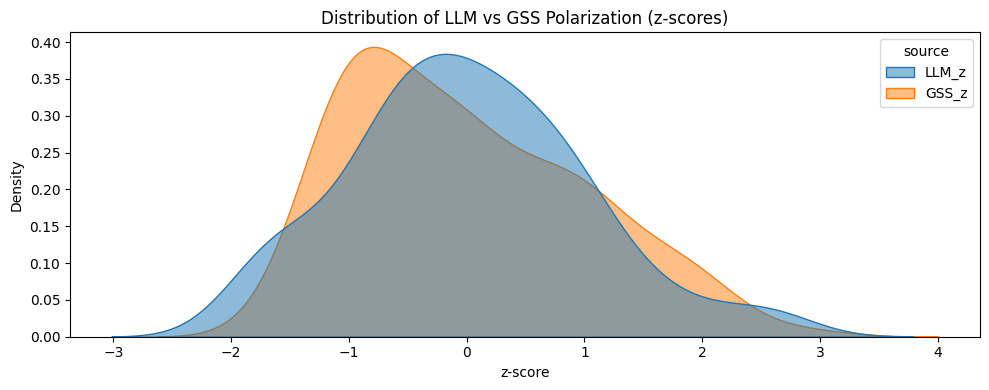

In [14]:
# Plot distributions (KDE) for LLM_z and GSS_z
m = df_pol_norm_sorted.reset_index().melt(id_vars='Topic', value_vars=['LLM_z', 'GSS_z'],
                                          var_name='source', value_name='z')

plt.figure(figsize=(10, 4))
sns.kdeplot(data=m, x='z', hue='source', fill=True, common_norm=False, alpha=0.5)
plt.xlabel('z-score')
plt.title('Distribution of LLM vs GSS Polarization (z-scores)')
plt.tight_layout()
plt.savefig("gss_zscore_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Area-Level Correlation

Average polarization within each policy area and compute correlation at the area level.

In [13]:
# Aggregate by area: compute mean LLM and GSS polarization per area
df_area_pol = df_pol_merged.groupby("area").agg({
    "Avg_Mahalanobis": "mean",
    "GSS_Polarization": "mean",
    "Topic": "count"
}).rename(columns={
    "Avg_Mahalanobis": "LLM_Mean",
    "GSS_Polarization": "GSS_Mean",
    "Topic": "n_topics"
}).reset_index()

# Compute area-level correlations
area_pearson_pol = df_area_pol["LLM_Mean"].corr(df_area_pol["GSS_Mean"], method="pearson")
area_spearman_pol = df_area_pol["LLM_Mean"].corr(df_area_pol["GSS_Mean"], method="spearman")

print(f"=== Area-Level Correlation (Politician Prompts) ===")
print(f"Number of areas: {len(df_area_pol)}")
print(f"Pearson r:  {area_pearson_pol:.3f}")
print(f"Spearman ρ: {area_spearman_pol:.3f}")

# Display area-level data sorted by GSS polarization
df_area_pol_sorted = df_area_pol.sort_values("GSS_Mean", ascending=False)
display(df_area_pol_sorted)

=== Area-Level Correlation (Politician Prompts) ===
Number of areas: 35
Pearson r:  0.592
Spearman ρ: 0.596


,area,LLM_Mean,GSS_Mean,n_topics
11,Ideology & Party Identification,1.787703,0.359472,1
17,Race: Government Intervention & Affirmative Ac...,1.795629,0.346669,5
34,Welfare & Redistribution Policy,1.742846,0.346525,3
0,Abortion: Circumstances for Legality & Support,1.820930,0.344497,11
16,Race: Explanations for Inequality,1.783987,0.303019,4
19,Religion in Public Life,1.766694,0.302068,2
20,Role of Government: Economics & Global Aid,1.762714,0.247385,8
7,Criminal Justice: Punishment & Drug Policy,1.757084,0.245559,4
24,Spending: Environment & Energy,1.770017,0.244199,3
12,Military & Foreign Aid,1.738704,0.239120,3


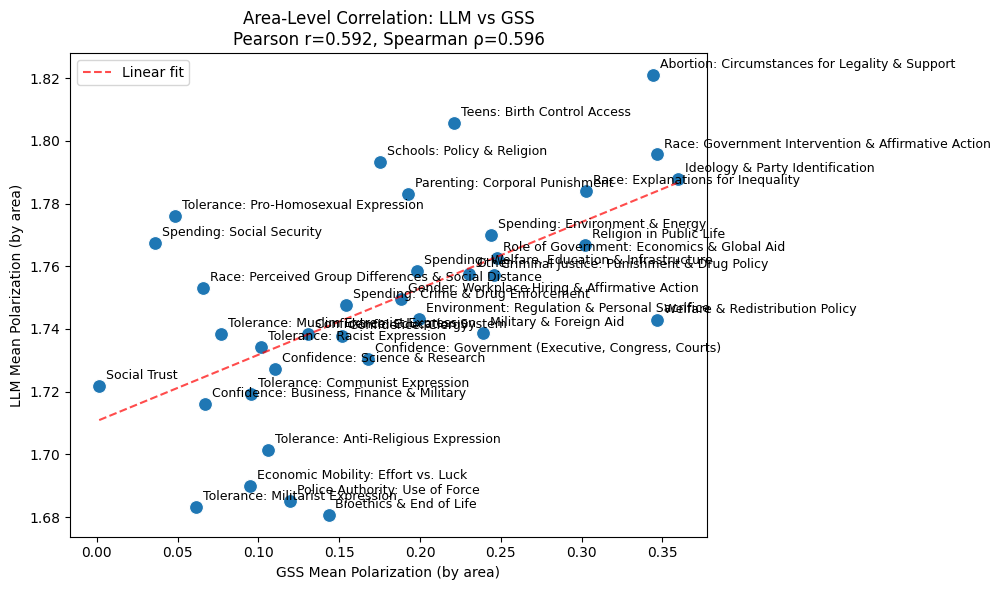

In [16]:
# Scatter plot of area-level polarization
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df_area_pol, x="GSS_Mean", y="LLM_Mean", s=100, ax=ax)

# Add area labels to points
for idx, row in df_area_pol.iterrows():
    ax.annotate(row["area"], (row["GSS_Mean"], row["LLM_Mean"]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)

# Add regression line
z = np.polyfit(df_area_pol["GSS_Mean"], df_area_pol["LLM_Mean"], 1)
p = np.poly1d(z)
x_line = np.linspace(df_area_pol["GSS_Mean"].min(), df_area_pol["GSS_Mean"].max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.7, label="Linear fit")

ax.set_xlabel("GSS Mean Polarization (by area)")
ax.set_ylabel("LLM Mean Polarization (by area)")
ax.set_title(f"Area-Level Correlation: LLM vs GSS\nPearson r={area_pearson_pol:.3f}, Spearman ρ={area_spearman_pol:.3f}")
ax.legend()

plt.tight_layout()
plt.savefig("gss_area_level_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. Area-Based Topic Sampling

Sample one topic per policy area to find combinations with highest correlation.

In [14]:
import random

# Prepare topic-to-area mapping
area_topics = df_pol_merged.groupby("area")["Topic"].apply(list).to_dict()
areas = list(area_topics.keys())

print(f"Policy areas: {len(areas)}")
for area, topics in area_topics.items():
    print(f"  {area}: {len(topics)} topics")

Policy areas: 35
  Abortion: Circumstances for Legality & Support: 11 topics
  Bioethics & End of Life: 1 topics
  Confidence: Business, Finance & Military: 3 topics
  Confidence: Clergy: 1 topics
  Confidence: Education System: 1 topics
  Confidence: Government (Executive, Congress, Courts): 3 topics
  Confidence: Science & Research: 4 topics
  Criminal Justice: Punishment & Drug Policy: 4 topics
  Economic Mobility: Effort vs. Luck: 1 topics
  Environment: Regulation & Personal Sacrifice: 15 topics
  Gender: Workplace Hiring & Affirmative Action: 4 topics
  Ideology & Party Identification: 1 topics
  Military & Foreign Aid: 3 topics
  Other: 3 topics
  Parenting: Corporal Punishment: 1 topics
  Police Authority: Use of Force: 5 topics
  Race: Explanations for Inequality: 4 topics
  Race: Government Intervention & Affirmative Action: 5 topics
  Race: Perceived Group Differences & Social Distance: 8 topics
  Religion in Public Life: 2 topics
  Role of Government: Economics & Global Aid

In [19]:
# Run sampling to find best topic combinations (politician prompts)
# Sample 120 topics total, ensuring at least one per area

N_TOTAL = 120
all_topics = df_pol_merged["Topic"].tolist()
results_pol = []

for i in range(100000):
    # First, ensure at least one topic per area
    sampled = [random.choice(area_topics[area]) for area in areas]
    
    # Then, sample remaining topics from all available (excluding already selected)
    remaining_count = N_TOTAL - len(sampled)
    remaining_pool = [t for t in all_topics if t not in sampled]
    sampled += random.sample(remaining_pool, min(remaining_count, len(remaining_pool)))
    
    sub = df_pol_merged[df_pol_merged["Topic"].isin(sampled)]
    r = sub["Avg_Mahalanobis"].corr(sub["GSS_Polarization"], method="pearson")
    results_pol.append((r, sampled))

# Sort and print best 15
top_results_pol = sorted(results_pol, key=lambda x: x[0], reverse=True)[:15]
print(f"=== Best Topic Combinations (Politician Prompts, n={N_TOTAL}) ===")
for idx, (r, topics) in enumerate(top_results_pol, 1):
    print(f"#{idx}: r={r:.3f} | n_topics={len(topics)}, topics removed: {set(all_topics) - set(topics)}") 

=== Best Topic Combinations (Politician Prompts, n=120) ===
#1: r=0.598 | n_topics=120, topics removed: {'racdif2', 'marblk', 'abhelp4', 'abhlth', 'abrape'}
#2: r=0.595 | n_topics=120, topics removed: {'grnsol', 'grnecon', 'racdif2', 'abhelp4', 'abhlth'}
#3: r=0.591 | n_topics=120, topics removed: {'govfnanc', 'grnecon', 'racdif2', 'colhomo', 'abhelp4'}
#4: r=0.590 | n_topics=120, topics removed: {'racdif2', 'abhelp4', 'eqwlth', 'natmass', 'abhlth'}
#5: r=0.590 | n_topics=120, topics removed: {'spkhomo', 'govineq1', 'abhelp4', 'grnexagg', 'abhlth'}
#6: r=0.589 | n_topics=120, topics removed: {'abnomore', 'racdif2', 'abhelp4', 'workwhts', 'abrape'}
#7: r=0.588 | n_topics=120, topics removed: {'grnecon', 'racdif2', 'racopen', 'polhitok', 'abhelp4'}
#8: r=0.584 | n_topics=120, topics removed: {'abnomore', 'grnecon', 'racdif1', 'abhelp4', 'abhlth'}
#9: r=0.584 | n_topics=120, topics removed: {'colath', 'racdif2', 'abhelp4', 'racdif3', 'abhlth'}
#10: r=0.583 | n_topics=120, topics removed: 

In [26]:
# Use best top-120 topics from previous sampling, aggregate by area and recompute area-level correlations
best_r_pol, best_topics_pol = top_results_pol[0]
print(f"Using best sampled set: r={best_r_pol:.3f}, n_topics={len(best_topics_pol)}")

sub = df_pol_merged[df_pol_merged["Topic"].isin(best_topics_pol)].copy()

df_area_sub = sub.groupby("area").agg({
    "Avg_Mahalanobis": "mean",
    "GSS_Polarization": "mean",
    "Topic": "count"
}).rename(columns={
    "Avg_Mahalanobis": "LLM_Mean",
    "GSS_Polarization": "GSS_Mean",
    "Topic": "n_topics"
}).reset_index()

area_pearson = df_area_sub["LLM_Mean"].corr(df_area_sub["GSS_Mean"], method="pearson")
area_spearman = df_area_sub["LLM_Mean"].corr(df_area_sub["GSS_Mean"], method="spearman")

print(f"Area-level correlations for top-{len(best_topics_pol)} topics:")
print(f"  Number of areas: {len(df_area_sub)}")
print(f"  Pearson r:  {area_pearson:.3f}")
print(f"  Spearman ρ: {area_spearman:.3f}")

display(df_area_sub.sort_values("GSS_Mean", ascending=False))

Using best sampled set: r=0.598, n_topics=120
Area-level correlations for top-120 topics:
  Number of areas: 35
  Pearson r:  0.598
  Spearman ρ: 0.602


,area,LLM_Mean,GSS_Mean,n_topics
0,Abortion: Circumstances for Legality & Support,1.813287,0.414985,8
16,Race: Explanations for Inequality,1.779750,0.401649,3
11,Ideology & Party Identification,1.787703,0.359472,1
17,Race: Government Intervention & Affirmative Ac...,1.795629,0.346669,5
34,Welfare & Redistribution Policy,1.742846,0.346525,3
19,Religion in Public Life,1.766694,0.302068,2
20,Role of Government: Economics & Global Aid,1.762714,0.247385,8
7,Criminal Justice: Punishment & Drug Policy,1.757084,0.245559,4
24,Spending: Environment & Energy,1.770017,0.244199,3
12,Military & Foreign Aid,1.738704,0.239120,3


In [21]:
# save df_pol_merged with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
df_pol_merged.to_pickle(f"df_pol_merged_gss_{timestamp}.pkl")

In [19]:
# Run sampling for ideology prompts (uncomment if using ideology pipeline)
# area_topics_ideo = df_ideo_merged.groupby("area")["Topic"].apply(list).to_dict()
# all_topics_ideo = df_ideo_merged["Topic"].tolist()
# results_ideo = []

# for i in range(100000):
#     sampled = [random.choice(area_topics_ideo[area]) for area in area_topics_ideo.keys()]
#     remaining_count = N_TOTAL - len(sampled)
#     remaining_pool = [t for t in all_topics_ideo if t not in sampled]
#     sampled += random.sample(remaining_pool, min(remaining_count, len(remaining_pool)))
    
#     sub = df_ideo_merged[df_ideo_merged["Topic"].isin(sampled)]
#     r = sub["Avg_Mahalanobis"].corr(sub["GSS_Polarization"], method="pearson")
#     results_ideo.append((r, sampled))

# top_results_ideo = sorted(results_ideo, key=lambda x: x[0], reverse=True)[:15]
# print(f"=== Best Topic Combinations (Ideology Prompts, n={N_TOTAL}) ===")
# for idx, (r, topics) in enumerate(top_results_ideo, 1):
#     print(f"#{idx}: r={r:.3f} | n_topics={len(topics)}")

## 11. Create Combined Results Table

In [20]:
def create_combined_table(df_politician, df_ideology):
    """Create a combined table with both prompt type results."""
    
    # Select key metrics
    cols = ['Topic', 'Avg_Mahalanobis', 'Avg_Total_Dispersion', 
            'Avg_PC1_Ratio', 'Avg_Davies_Bouldin', 'Polarization_CoG']
    
    df_pol = df_politician[cols].copy()
    df_ideo = df_ideology[cols].copy()
    
    # Rename columns to distinguish
    df_pol = df_pol.rename(columns={
        c: f"Pol_{c}" if c != 'Topic' else c for c in cols
    })
    df_ideo = df_ideo.rename(columns={
        c: f"Ideo_{c}" if c != 'Topic' else c for c in cols
    })
    
    # Merge
    df_combined = df_pol.merge(df_ideo, on='Topic', how='outer')
    
    return df_combined

df_combined = create_combined_table(df_politician, df_ideology)
print(f"Combined table shape: {df_combined.shape}")
df_combined.head(10)

NameError: name 'df_ideology' is not defined

In [ ]:
# Save combined results
df_combined.to_csv(f"llm_gss_polarization_combined_{timestamp}.csv", index=False)
df_combined.to_pickle(f"llm_gss_polarization_combined_{timestamp}.pkl")
print(f"Saved combined results with timestamp: {timestamp}")

## 12. Summary Statistics

In [ ]:
print("=" * 60)
print("GSS POLARIZATION ANALYSIS SUMMARY")
print("=" * 60)

print(f"\nTotal GSS topics analyzed: {len(TOPICS_SUBSET)}")
print(f"Topics matched with survey data: {len(df_pol_merged)}")
print(f"Policy areas: {len(df_area_pol)}")

print(f"\n--- Topic-Level Correlation (Politician Prompts) ---")
print(f"Pearson r:  {pol_pearson:.3f}")
print(f"Spearman ρ: {pol_spearman:.3f}")

print(f"\n--- Area-Level Correlation (Politician Prompts) ---")
print(f"Pearson r:  {area_pearson_pol:.3f}")
print(f"Spearman ρ: {area_spearman_pol:.3f}")

# print(f"\n--- Topic-Level Correlation (Ideology Prompts) ---")
# print(f"Pearson r:  {ideo_pearson:.3f}")
# print(f"Spearman ρ: {ideo_spearman:.3f}")

print(f"\n--- Best Subsets (Politician) ---")
best_r_pol, best_topics_pol = top_results_pol[0]
print(f"Best r: {best_r_pol:.3f}")
print(f"Topics: {best_topics_pol}")

## 13. Policy Area Analysis

In [ ]:
# Compute mean correlations by policy area
area_stats = df_pol_merged.groupby("area").agg({
    "Avg_Mahalanobis": "mean",
    "GSS_Polarization": "mean",
    "Topic": "count"
}).rename(columns={"Topic": "n_topics"})

area_stats = area_stats.sort_values("GSS_Polarization", ascending=False)
print("=== Mean Polarization by Policy Area ===")
display(area_stats)

In [ ]:
# Bar plot comparing LLM vs GSS polarization by area
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(area_stats))
width = 0.35

# Normalize for comparison
llm_norm = (area_stats["Avg_Mahalanobis"] - area_stats["Avg_Mahalanobis"].min()) / (area_stats["Avg_Mahalanobis"].max() - area_stats["Avg_Mahalanobis"].min())
gss_norm = (area_stats["GSS_Polarization"] - area_stats["GSS_Polarization"].min()) / (area_stats["GSS_Polarization"].max() - area_stats["GSS_Polarization"].min())

ax.bar(x - width/2, llm_norm, width, label='LLM (normalized)', alpha=0.8)
ax.bar(x + width/2, gss_norm, width, label='GSS (normalized)', alpha=0.8)

ax.set_ylabel('Normalized Polarization')
ax.set_title('LLM vs GSS Polarization by Policy Area')
ax.set_xticks(x)
ax.set_xticklabels(area_stats.index, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig("gss_area_comparison.png", dpi=150, bbox_inches='tight')
plt.show()